In [66]:
import igraph as ig
import matplotlib.pyplot as plt
from igraph import plot as ig_plot
from msccl.language.ir import *
from msccl.language.rank_dag import *

def visualize_rank_dag(operations): # pragma: no cover
    frontier = []
    nnodes = 0
    vertex_label = []
    vertex_colors = []
    edges = []
    visited = set()
    colors = ['red', 'green', 'blue', 'yellow', 'teal', 'pink', 'purple', 'orange']

    def add_node(op, nnodes, vertex_label, vertex_colors):
        if op.num == -1:
            op.num = nnodes
            nnodes += 1
            # Add new node to graph
            if op.inst == Instruction.start:
                vertex_label.append(f'Chunk {op.src.index} Rank {op.src.rank}')
            elif op.inst == Instruction.send:
                vertex_label.append(f'S to Rank {op.dst.rank}')
            elif op.inst == Instruction.recv:
                vertex_label.append(f'R from {op.src.rank}')
            elif op.inst == Instruction.recv_reduce_copy:
                vertex_label.append(f'RRC from {op.src.rank}')
            else:
                vertex_label.append(f'{op.inst}')

            # Add colors 
            if op.inst == Instruction.start:
                vertex_colors.append('gray')
            else:
                vertex_colors.append(colors[op.tb % len(colors)])
        return nnodes

    for slot, op in operations.items():
        if len(op.prev) == 0: 
            frontier.append(op)

    while len(frontier) > 0:
        op = frontier[0]

        if op in visited:
            frontier = frontier[1:]
        else:
            nnodes = add_node(op, nnodes, vertex_label, vertex_colors)

        for next_op in op.next:
            nnodes = add_node(next_op, nnodes, vertex_label, vertex_colors)
            edges.append([op.num, next_op.num])
            frontier = frontier[1:] + list(op.next)
        visited.add(op)

    # Adjust layout for better readability
    g = ig.Graph(nnodes, edges, directed=True)
    layout = g.layout(layout=ig.Graph.layout_reingold_tilford)  # Use a tree-like layout

    # Increase vertex label font size and adjust vertex and edge settings
    visual_style = {
        "vertex_label": vertex_label,
        "vertex_label_dist": 2,
        "vertex_label_size": 8,  # Increase label size
        "vertex_color": vertex_colors,
        "edge_arrow_size": 1.5,   # Increase arrow size
        "edge_width": 2,          # Thicker edges
        "layout": layout,
        "bbox": (800, 800),       # Larger plot size
        "margin": 50              # Increase margins to avoid label clipping
    }

    # Plot the graph with the visual style
    fig, ax = plt.subplots(figsize=(8,8))
    ig.plot(g, **visual_style, target="graph.png")

    # Load and display the image with matplotlib
    img = plt.imread("graph.png")
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(img)
    ax.axis('off')  # Hide axes
    plt.show()


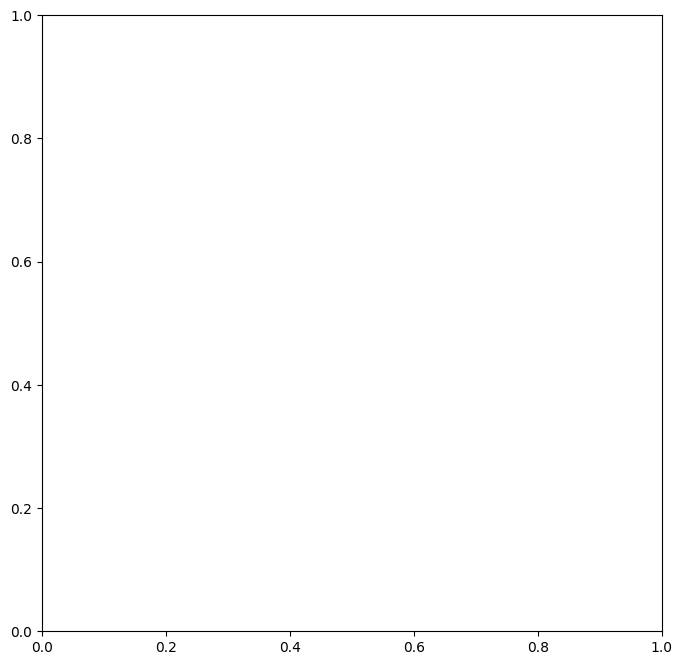

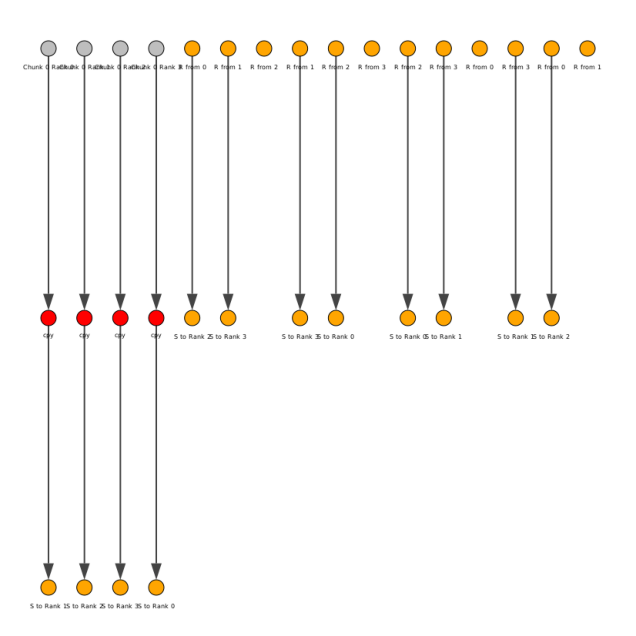

In [67]:
import pickle

# Load the object from the file
with open("dag.pkl", "rb") as f:
    loaded_obj = pickle.load(f)

visualize_rank_dag(loaded_obj.operations)
